In [13]:
from gym_pybullet_drones.envs.BaseAviary import DroneModel
from ModDSLPID import ModDSLPID
from pid_interaction_aviary_1 import PIDInteractionAviary1
import matplotlib.pyplot as plt
import numpy as np

In [14]:
ep_len = 2 # sec

drone_model = DroneModel.CF2X

env = PIDInteractionAviary1(drone_model=drone_model, ep_len=ep_len, freq=240)

ctrl_timestep = 1/env.SIM_FREQ
ctrl = ModDSLPID(drone_model=drone_model)

P_COEFF_TOR = np.array([70000., 70000., 60000.])
I_COEFF_TOR = np.array([0., 0., 500.])
D_COEFF_TOR = np.array([20000., 20000., 12000.])

ctrl.setPIDCoefficients(p_coeff_att=P_COEFF_TOR,
                        i_coeff_att=I_COEFF_TOR,
                        d_coeff_att=D_COEFF_TOR)

cumm_reward = 0
curr_rpys = []
state_history = []
computed_target_rpys = []
obs = env.reset()
for i in range(ep_len*env.SIM_FREQ):
    state = obs[:20]
    state_history.append(state)
    
    target_pos = obs[20:23]
    target_vel = obs[23:]
    rpms, _, computed_target_rpy = ctrl.computeControlFromState(control_timestep=ctrl_timestep,
                                        state=state,
                                        target_pos=target_pos,
                                        target_vel=target_vel
                                        )
    computed_target_rpys.append(computed_target_rpy)
    curr_rpys.append(obs[7:10])

    obs, reward, done, info = env.step(rpms)
    cumm_reward += np.sum(np.abs(computed_target_rpy-obs[7:10]))

print(cumm_reward)


[INFO] BaseAviary.__init__() loaded parameters from the drone's .urdf:
[INFO] m 0.027000, L 0.039700,
[INFO] ixx 0.000014, iyy 0.000014, izz 0.000022,
[INFO] kf 0.000000, km 0.000000,
[INFO] t2w 2.250000, max_speed_kmh 30.000000,
[INFO] gnd_eff_coeff 11.368590, prop_radius 0.023135,
[INFO] drag_xy_coeff 0.000001, drag_z_coeff 0.000001,
[INFO] dw_coeff_1 2267.180000, dw_coeff_2 0.160000, dw_coeff_3 -0.110000


c:\Users\awals\AppData\Local\Programs\Python\Python39\lib\site-packages\gym\logger.py:34: UserWarning: WARN: Box bound precision lowered by casting to float32
  warnings.warn(colorize("%s: %s" % ("WARN", msg % args), "yellow"))


2.015871853093125


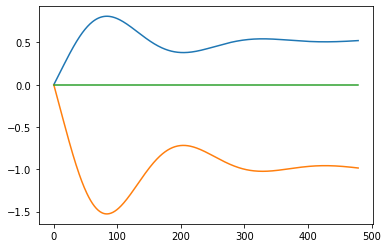

In [15]:
plt.plot(np.array(computed_target_rpys)*180/np.pi)
plt.show()

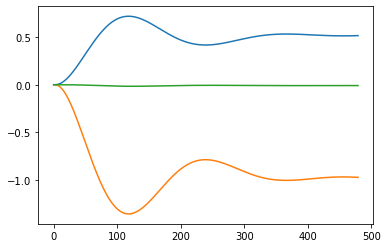

In [16]:
plt.plot(np.array(curr_rpys)*180/np.pi)
plt.show()

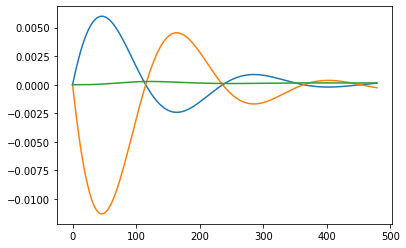

In [17]:
plt.plot(np.array(computed_target_rpys)-np.array(curr_rpys))
plt.show()

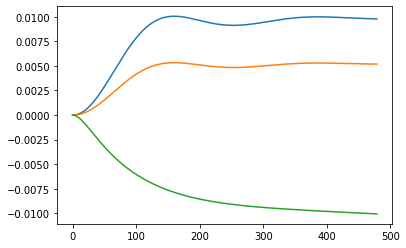

In [18]:
positions = [state[:3]-target_pos for state, target_pos in zip(state_history, env.TARGET_POS)]
plt.plot(positions)
plt.show()